# RB EDA 01 — Coverage

**Stage 6 (PROJECT_PLAN §3 `[6] eda`).** How the ranking *universe* and the feature *schema* change over time. All logic lives in `position_predictor.eda.analyze` (the headless `scripts/run_eda.py` calls the same functions); this notebook just renders the tables and the saved figure.

Reads the Stage-4 processed matrix (`data/processed/football_rb_features.parquet`). Run `make fetch build features` first if it is missing.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parents[2] if Path.cwd().name == "rb" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from IPython.display import Image, display
from position_predictor.utils.config import Config
from position_predictor.eda.analyze import run_eda

cfg = Config.load(str(ROOT / "config" / "football_rb.yaml"))
# Compute every EDA table from the shared library + (re)write the reports artifacts.
tables = run_eda(cfg, write=True)
RESULTS = ROOT / "reports" / "results"
FIGURES = ROOT / "reports" / "figures"
print("player-seasons:", int(tables["universe"]["n_player_seasons"].sum()))

player-seasons: 4200


## 1. The RB universe over time + next-season target availability
`n_active_next` is the modelable target pool (season *N+1* PPG observed). The **latest feature season is fully `censored`** — its N+1 has not happened yet (or is unpublished by nflverse), so its target coverage is 0. This is structural, not retirement.

In [2]:
uni = tables["universe"]
display(uni)

,season,era,n_player_seasons,n_active_next,n_injured_next,n_retired_next,target_coverage,mean_games,mean_ppg
0,1999,boxscore,165,118,5,42,0.715152,9.157576,5.943820
1,2000,boxscore,158,114,5,39,0.721519,8.968354,6.343722
2,2001,boxscore,153,116,7,30,0.758170,9.640523,6.224592
3,2002,boxscore,160,122,7,31,0.762500,9.643750,6.421301
4,2003,boxscore,161,131,8,22,0.813665,9.490683,6.598635
5,2004,boxscore,176,127,8,41,0.721591,8.482955,6.573477
6,2005,boxscore,162,124,6,32,0.765432,9.012346,6.591718
7,2006,boxscore,162,106,9,47,0.654321,9.024691,6.392289
8,2007,boxscore,157,120,5,32,0.764331,9.229299,6.699411
9,2008,boxscore,168,125,6,37,0.744048,8.767857,6.563229


## 2. Feature-block coverage by era
Confirms the nested era schema (§6.3): the era-gated blocks (`snap_usage` 2012+, `ngs_efficiency` 2016+) are absent before their era and populated within it; the always-on blocks stay covered throughout. `in_era_schema` marks which blocks each era's model is allowed to use.

In [3]:
display(tables["block_coverage"])

,era,block,in_era_schema,n_cols,coverage
0,boxscore,production,True,11,1.000000
1,boxscore,volume,True,10,1.000000
2,boxscore,team_context,True,5,1.000000
3,boxscore,efficiency,True,12,0.925257
4,boxscore,player_attrs,True,8,0.971734
5,boxscore,availability,True,7,1.000000
6,boxscore,snap_usage,False,3,0.000000
7,boxscore,trajectory,True,6,0.748298
8,boxscore,regression_mean,True,4,0.763420
9,boxscore,ngs_efficiency,False,9,0.222222


## 3. Era boundaries, drawn from the data
Per-season non-null fraction of the era-gated columns — `snap_share` jumps at **2012**, the NGS columns at **2016**, exactly where the era partition places the boundaries.

In [4]:
cc = tables["column_coverage"]
display(cc.pivot(index="season", columns="column", values="coverage").round(2))

column,avg_separation,ngs_efficiency,rush_pct_over_expected,ryoe_per_att,snap_share
season,,,,,
1999,0.00,0.00,0.00,0.00,0.00
2000,0.00,0.00,0.00,0.00,0.00
2001,0.00,0.00,0.00,0.00,0.00
2002,0.00,0.00,0.00,0.00,0.00
2003,0.00,0.00,0.00,0.00,0.00
2004,0.00,0.00,0.00,0.00,0.00
2005,0.00,0.00,0.00,0.00,0.00
2006,0.00,0.00,0.00,0.00,0.00
2007,0.00,0.00,0.00,0.00,0.00


## 4. NGS coverage is *signal*, not noise
NGS rushing coverage is high for the top backs and collapses for the fringe (the §7.3 finding that motivates the Stage-8 NGS-block ablation). A top back missing NGS *rushing* is typically a receiving-profile RB (NGS rushing has an attempt threshold).

In [5]:
display(tables["ngs_tier_coverage"])

,tier,n,has_ngs_rush,has_ngs_rec
0,<= 12,108,0.777778,0.000000
1,13-24,108,0.759259,0.000000
2,25-36,108,0.740741,0.000000
3,37+,1116,0.096774,0.000896


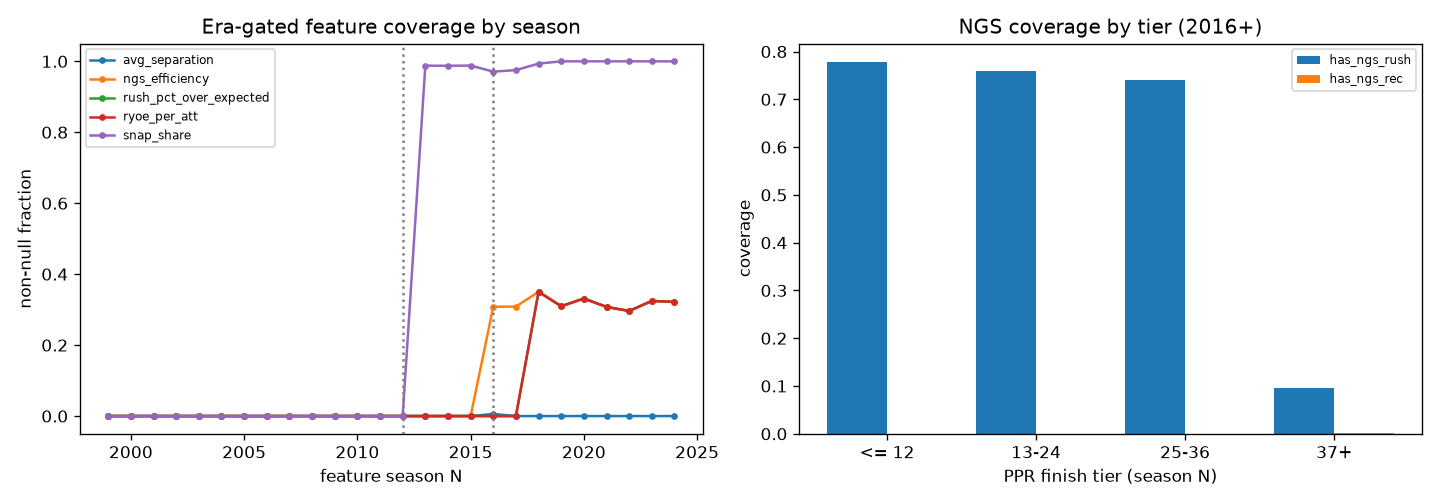

In [6]:
display(Image(str(FIGURES / "eda_football_rb_coverage.png")))

### Findings
- The ranking universe is ~140–170 RB seasons/year; the modelable (active-next) pool is ~70–80% of it, the rest retiring or missing the full N+1 season.
- The **latest feature season is entirely censored** — correctly excluded from the target, available only as a *prediction* input for the live board.
- Era boundaries (snaps 2012, NGS 2016) are visible in the coverage curves and justify era-separate modeling rather than imputing structurally-absent columns.
- NGS coverage ≈75% for top-36 vs ≈10% for RB37+ → keep NGS with coverage flags and let Stage 8 ablate it, rather than dropping it or restricting the universe.